## 1. Импорты и настройка путей

In [2]:
from pathlib import Path
import sys
import time
import warnings
warnings.filterwarnings('ignore')

import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

PROJECT_ROOT = Path(r"C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis")
if not PROJECT_ROOT.exists():
    PROJECT_ROOT = Path.cwd()

OUTPUT_DIR  = PROJECT_ROOT / "outputs"
FIGURES_DIR = PROJECT_ROOT / "figures"
SRC_DIR     = PROJECT_ROOT / "src"
for p in (OUTPUT_DIR, FIGURES_DIR):
    p.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(SRC_DIR))

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

OLLAMA_URL   = "http://localhost:11434/api/generate"
OLLAMA_MODEL = "qwen2.5:7b"

OUTPUT_FILE = OUTPUT_DIR / "summaries_full_corpus.csv"

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis


## 2. Проверка соединения с Ollama

In [3]:
def check_ollama() -> bool:
    try:
        resp = requests.get("http://localhost:11434", timeout=5)
        return resp.status_code == 200
    except Exception:
        return False

if check_ollama():
    print("Ollama запущена и доступна.")
else:
    print("Ollama недоступна.")

Ollama запущена и доступна.


## 3. Загрузка корпуса и метаданных

In [4]:
from text_preprocessing import read_text_file, extract_metadata

df = pd.read_csv(OUTPUT_DIR / "clean_corpus.csv")
df["tokens"] = df["tokens"].apply(lambda x: x.split() if isinstance(x, str) else x)

# Только документы с непустым текстом
df = df[
    df["clean_text"].notna() & (df["clean_text"].str.len() > 100)
].reset_index(drop=True)

# Извлекаются метаданные из исходных .tex файлов (title, author), abstract здесь намеренно не используется — для большинства документов его нет
print("Извлечение метаданных из .tex файлов...")
meta_rows = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Метаданные"):
    try:
        raw = read_text_file(Path(row["path"]))
        meta = extract_metadata(raw)
    except Exception:
        meta = {"title": "", "author": "", "abstract": ""}
    meta_rows.append({"title": meta.get("title", ""), "author": meta.get("author", "")})

meta_df = pd.DataFrame(meta_rows)
df = pd.concat([df.reset_index(drop=True), meta_df], axis=1)

# Подгрузка доминирующих тем BigARTM
topics_path = OUTPUT_DIR / "bigartm_documents_topics.csv"
if topics_path.exists():
    topics_df = pd.read_csv(topics_path)[["filename", "dominant_topic"]]
    df = df.merge(topics_df, on="filename", how="left")
    print("Темы BigARTM загружены.")
else:
    df["dominant_topic"] = "—"
    print("Файл с темами не найден.")

# Ограничение корпуса 100 документами
SAMPLE_SIZE = 100
df = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=42).reset_index(drop=True)

print(f"\nДокументов для реферирования: {len(df)} (выборка из полного корпуса)")

Извлечение метаданных из .tex файлов...


Метаданные: 100%|██████████| 6385/6385 [00:12<00:00, 513.48it/s]


Темы BigARTM загружены.

Документов для реферирования: 100 (выборка из полного корпуса)


## 4. Функция генерации аннотации

In [5]:
MAX_TEXT_CHARS = 4000

PROMPT_TEMPLATE = """Ты — научный редактор, специализирующийся на математических публикациях.
Напиши краткую аннотацию (3–5 предложений) следующей математической статьи на русском языке.
Аннотация должна отражать: основную тему и задачу, используемые методы, главный результат.
Пиши только аннотацию, без пояснений и вводных фраз.

Текст статьи:
{text}

Аннотация:"""


def generate_summary(
    text: str,
    model: str = OLLAMA_MODEL,
    max_chars: int = MAX_TEXT_CHARS,
    timeout: int = 120,
) -> str:
    #Отправляет текст в Ollama и возвращает сгенерированную аннотацию
    prompt = PROMPT_TEMPLATE.format(text=text[:max_chars])
    payload = {
        "model":  model,
        "prompt": prompt,
        "stream": False,
        "options": {
            "temperature": 0.3,
            "top_p":       0.9,
            "num_predict": 300,
        },
    }
    try:
        resp = requests.post(OLLAMA_URL, json=payload, timeout=timeout)
        resp.raise_for_status()
        return resp.json().get("response", "").strip()
    except requests.exceptions.Timeout:
        return "[ОШИБКА: таймаут]"
    except Exception as e:
        return f"[ОШИБКА: {e}]"


# Тест на первом документе
print("Тест генерации (первый документ)...")
test_summary = generate_summary(df["clean_text"].iloc[0])
print(f"Файл:      {df['filename'].iloc[0]}")
print(f"Аннотация: {test_summary}")

Тест генерации (первый документ)...
Файл:      10-9-2003.tex
Аннотация: Статья исследует динамику неньютоновских жидкостей с использованием качественного анализа уравнения Оствальда-Виль. Целью является изучение поведения интегральных кривых вблизи особой точки и бифуркационных кривых. Методы включают применение теории инвариантных уравнений и качественного анализа динамической системы. Главный результат — описание качественного поведения интегральных кривых, в том числе переход от узла к фокусу при изменении параметра.


## 5. Генерация аннотаций с поддержкой продолжения

Ноутбук автоматически пропускает уже обработанные файлы — можно запускать повторно после прерывания.

In [6]:
# Загрузка уже обработанных результатов (если файл существует)
SAVE_COLS = ["filename", "title", "author", "dominant_topic", "generated_summary"]

if OUTPUT_FILE.exists():
    done_df = pd.read_csv(OUTPUT_FILE, encoding="utf-8")
    done_filenames = set(done_df["filename"].tolist())
    print(f"Найден файл с результатами: уже обработано {len(done_filenames)} документов.")
else:
    done_df = pd.DataFrame(columns=SAVE_COLS)
    done_filenames = set()
    print("Генерация начинается с нуля.")

# Документы, которые ещё не обработаны
todo_df = df[~df["filename"].isin(done_filenames)].reset_index(drop=True)
print(f"Осталось обработать: {len(todo_df)} документов из {len(df)}")

if len(todo_df) == 0:
    print("Все документы уже обработаны.")

Генерация начинается с нуля.
Осталось обработать: 100 документов из 100


In [7]:
# Сохранение каждые CHECKPOINT_EVERY документов - защита от потери прогресса
CHECKPOINT_EVERY = 50

new_records = []
start_time  = time.time()

for i, (_, row) in enumerate(tqdm(todo_df.iterrows(), total=len(todo_df),
                                   desc="Генерация аннотаций")):
    summary = generate_summary(row["clean_text"])

    new_records.append({
        "filename": row["filename"],
        "title": row.get("title", ""),
        "author": row.get("author", ""),
        "dominant_topic": row.get("dominant_topic", "—"),
        "generated_summary": summary,
    })

    # Чекпоинт: дописываются результаты к файлу
    if (i + 1) % CHECKPOINT_EVERY == 0 or (i + 1) == len(todo_df):
        checkpoint_df = pd.DataFrame(new_records)
        write_header = not OUTPUT_FILE.exists()
        checkpoint_df.to_csv(
            OUTPUT_FILE, mode="a", header=write_header,
            index=False, encoding="utf-8"
        )
        new_records = []  # Очистка буфера
        elapsed = time.time() - start_time
        done_so_far = i + 1 + len(done_filenames)
        remaining = len(df) - done_so_far
        eta_hours = (elapsed / (i + 1)) * remaining / 3600
        print(f"  [{done_so_far}/{len(df)}] Сохранено. "
              f"Прошло: {elapsed/60:.1f} мин. "
              f"Осталось: ~{eta_hours:.1f} ч.")

total_elapsed = time.time() - start_time
print(f"\nГенерация завершена. Время: {total_elapsed/60:.1f} мин.")

Генерация аннотаций:  50%|█████     | 50/100 [51:16<54:04, 64.90s/it]  

  [50/100] Сохранено. Прошло: 51.3 мин. Осталось: ~0.9 ч.


Генерация аннотаций: 100%|██████████| 100/100 [1:51:09<00:00, 66.70s/it] 

  [100/100] Сохранено. Прошло: 111.2 мин. Осталось: ~0.0 ч.

Генерация завершена. Время: 111.2 мин.


## 6. Просмотр результатов

In [8]:
results_df = pd.read_csv(OUTPUT_FILE, encoding="utf-8")

# Статистика по ошибкам
errors = results_df["generated_summary"].str.startswith("[ОШИБКА").sum()
success = len(results_df) - errors

print(f"Всего документов:        {len(results_df)}")
print(f"Успешно сгенерировано:   {success}")
print(f"Ошибок при генерации:    {errors}")
print(f"\nПример аннотации:")
for _, row in results_df.head(3).iterrows():
    print(f"Файл:    {row['filename']}")
    if pd.notna(row.get('title')) and str(row['title']).strip():
        print(f"Заголовок: {str(row['title'])[:80]}")
    print(f"Тема:    {row['dominant_topic']}")
    print(f"Аннотация: {str(row['generated_summary'])[:300]}")

Всего документов:        100
Успешно сгенерировано:   99
Ошибок при генерации:    1

Пример аннотации:
Файл:    10-9-2003.tex
Заголовок: О точности приближенных симметрий уравнений динамики неньютоновской жидкости и и
Тема:    topic_3
Аннотация: Статья исследует динамику неньютоновских жидкостей с использованием качественного анализа уравнения Оствальда-Виль. Целью является изучение инвариантных кривых и особенных точек на плоскости, а также их поведения при изменении параметров. Методы включают анализ асимптотик и бифуркационных кривых для
Файл:    borodak.tex
Тема:    topic_12
Аннотация: Статья посвящена анализу и моделированию работы распределенных автоматизированных систем управления специального назначения на основе сетецентрической концепции. Используются методы вероятностного анализа и теории очередей для оценки качества системы в зависимости от нагрузки. Основной результат — п
Файл:    kuznecova.tex
Заголовок: Моделирование теплового состояния композиционных материалов на основ

## 7. Визуализация результатов

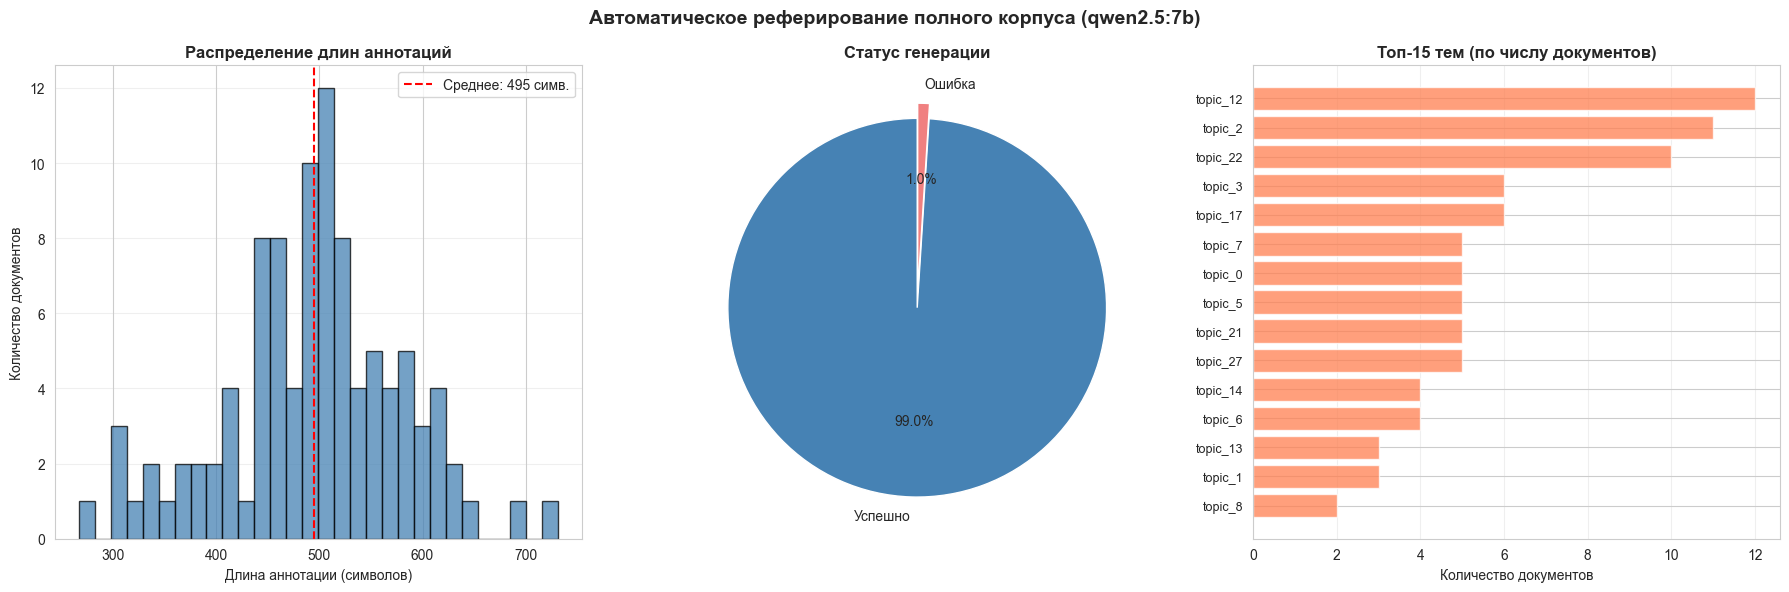

Сохранено: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\figures\summarization_full_corpus.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Длины сгенерированных аннотаций
ax = axes[0]
summary_lengths = results_df["generated_summary"].dropna().apply(
    lambda x: len(x) if not str(x).startswith("[ОШИБКА") else 0
)
ax.hist(summary_lengths[summary_lengths > 0], bins=30,
        color="steelblue", alpha=0.75, edgecolor="black")
ax.axvline(summary_lengths[summary_lengths > 0].mean(), color="red",
           linestyle="--",
           label=f"Среднее: {summary_lengths[summary_lengths > 0].mean():.0f} симв.")
ax.set_xlabel("Длина аннотации (символов)")
ax.set_ylabel("Количество документов")
ax.set_title("Распределение длин аннотаций", fontweight="bold")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Успех vs Ошибки
ax = axes[1]
ax.pie([success, errors],
       labels=["Успешно", "Ошибка"],
       autopct="%1.1f%%",
       colors=["steelblue", "lightcoral"],
       explode=(0.03, 0.05),
       startangle=90)
ax.set_title("Статус генерации", fontweight="bold")

# Распределение по темам (топ-15)
ax = axes[2]
if "dominant_topic" in results_df.columns:
    topic_counts = (
        results_df[results_df["dominant_topic"] != "—"]["dominant_topic"]
        .value_counts()
        .head(15)
    )
    ax.barh(range(len(topic_counts)), topic_counts.values,
            color="coral", alpha=0.75)
    ax.set_yticks(range(len(topic_counts)))
    ax.set_yticklabels(topic_counts.index.astype(str), fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Количество документов")
    ax.set_title("Топ-15 тем (по числу документов)", fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
else:
    ax.axis("off")

plt.suptitle(
    f"Автоматическое реферирование полного корпуса ({OLLAMA_MODEL})",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "summarization_full_corpus.png", dpi=300, bbox_inches="tight")
plt.show()
print("Сохранено:", FIGURES_DIR / "summarization_full_corpus.png")

## 8. Примеры аннотаций по темам

In [10]:
# По одному примеру из каждой из 5 наиболее представленных тем
if "dominant_topic" in results_df.columns:
    top_topics = (
        results_df[results_df["dominant_topic"] != "—"]["dominant_topic"]
        .value_counts()
        .head(5)
        .index.tolist()
    )

    print("Примеры аннотаций по топ-5 темам:")
    for topic in top_topics:
        subset = results_df[
            (results_df["dominant_topic"] == topic) &
            (~results_df["generated_summary"].str.startswith("[ОШИБКА", na=True))
        ]
        if subset.empty:
            continue
        row = subset.iloc[0]
        print(f"Тема:      {topic}")
        print(f"Файл:      {row['filename']}")
        if pd.notna(row.get('title')) and str(row['title']).strip():
            print(f"Заголовок: {str(row['title'])[:80]}")
        print(f"Аннотация: {str(row['generated_summary'])[:400]}")

Примеры аннотаций по топ-5 темам:
Тема:      topic_12
Файл:      borodak.tex
Аннотация: Статья посвящена анализу и моделированию работы распределенных автоматизированных систем управления специального назначения на основе сетецентрической концепции. Используются методы вероятностного анализа и теории очередей для оценки качества системы в зависимости от нагрузки. Основной результат — предложенная модель позволяет вычислить вероятность отказа обслуживания запросов на основе пуассоновс
Тема:      topic_2
Файл:      2023_07_09_2f80ee461bde53095748g.tex
Аннотация: Статья посвящена исследованию уайтхедовых гомоморфизмов и их свойств в контексте стабильного гомотопического спектра. Автор рассматривает специальную конструкцию отображений, задаваемых продолжением отображения верхней полусферы на сферу и нижней полусферы. Основным результатом является построение нетривиального уайтхедова гомоморфизма бесконечной серии гомотопических групп сфер, который играет кл
Тема:      topic_22
Файл:      2

## 9. Итоговая статистика

In [11]:
valid_summaries = results_df[
    ~results_df["generated_summary"].str.startswith("[ОШИБКА", na=True)
]["generated_summary"]

lengths = valid_summaries.apply(len)

print("Итоговая статистика реферирования")
print(f"  Всего документов:       {len(results_df)}")
print(f"  Успешно:                {success}  ({100*success/len(results_df):.1f}%)")
print(f"  Ошибок:                 {errors}")
print(f"  Средняя длина аннотации: {lengths.mean():.0f} символов")
print(f"  Медиана длины:           {lengths.median():.0f} символов")
print(f"  Мин/макс длина:          {lengths.min()} / {lengths.max()} символов")
print(f"\n  Файл сохранён: {OUTPUT_FILE}")

Итоговая статистика реферирования
  Всего документов:       100
  Успешно:                99  (99.0%)
  Ошибок:                 1
  Средняя длина аннотации: 495 символов
  Медиана длины:           500 символов
  Мин/макс длина:          267 / 731 символов

  Файл сохранён: C:\Users\anmrt\Desktop\Useful shit\Диплом\graduation_thesis\outputs\summaries_full_corpus.csv
